In [20]:
# standard python imports
import matplotlib.pyplot as plt
import numpy as np

# tidy3d imports
import tidy3d as td
import tidy3d.web as webs
from tidy3d import material_library

period = 620.0 nm, duty_cycle = 0.500
hole_diameter = 310.0 nm, hole_radius = 155.0 nm
grating_length = 9.92 um
mirror_shift = 300.0 nm
input_wg_length = 1.50 um
Grid cells: [672, 70, 251]


Text(0.5, 1.0, '3D SOI coupler: input waveguide + 10 um grating + Au mirror shift')

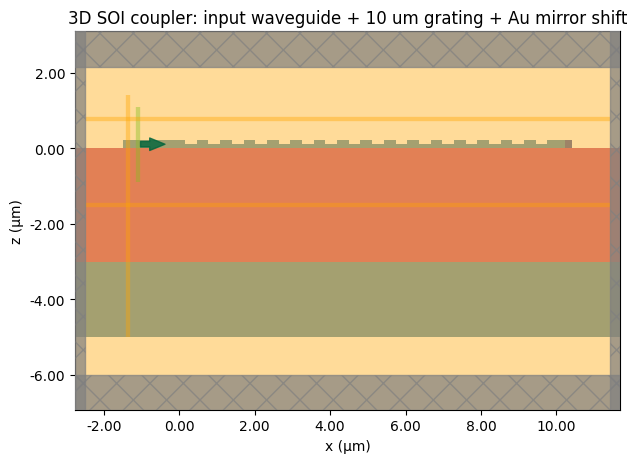

In [40]:
# paper-inspired 3D grating coupler on SOI with input waveguide, continuous slab, y-periodic boundary, and Au mirror shift
freq0 = td.C_0 / 1.55
wvl0 = td.C_0 / freq0
fwidth = freq0 / 10
freqs = np.linspace(freq0 - fwidth, freq0 + fwidth, 11)

si = material_library['cSi']['Li1993_293K']
sio2 = material_library['SiO2']['Palik_Lossless']
au = material_library['Au']['JohnsonChristy1972']
air = td.Medium(permittivity=1.0)

# SOI stack dimensions (micron)
t_si = 0.22
t_box = 3.0
t_sub = 2.0
t_air = 1.2

# Grating and mirror parameters (paper-style)
grating_period_nm = 620.0
duty_cycle = 0.5
etch_depth = 0.10
num_periods = 10
mirror_shift_nm = 300.0
period = grating_period_nm * 1e-3
mirror_shift = mirror_shift_nm * 1e-3

# Diameter follows duty_cycle * period, radius is half the diameter.
hole_diameter = duty_cycle * period
hole_radius = 0.5 * hole_diameter

# Match the fiber-core-scale grating length (~10 um).
grating_length = 10.0
num_periods = int(np.round(grating_length / period))
grating_length = num_periods * period
mirror_thickness_x = 0.20

# Input waveguide before grating and continuous slab up to mirror start
input_wg_length = 1.5
x_grating_start = 0.0
x_grating_end = grating_length
x_slab_start = -input_wg_length
x_slab_end = x_grating_end + mirror_shift
x_mirror_start = x_slab_end
x_mirror_end = x_mirror_start + mirror_thickness_x

# 3D width in y (still periodic)
wg_width = 0.50
sim_width_y = wg_width

# Simulation padding
buffer_x_left = 1.0
buffer_x_right = 1.0
buffer_z_top = 0.75
buffer_z_bottom = 1.0

# Vertical references
z_si_bottom = 0.0
z_si_top = z_si_bottom + t_si
z_box_top = z_si_bottom
z_box_bottom = z_box_top - t_box
z_sub_top = z_box_bottom
z_sub_bottom = z_sub_top - t_sub
z_air_top = z_si_top + t_air

# SOI layers
box_layer = td.Structure(
    geometry=td.Box(
        center=(0.5 * (x_slab_start + x_mirror_end), 0, 0.5 * (z_box_top + z_box_bottom)),
        size=(td.inf, td.inf, t_box),
    ),
    medium=sio2,
)
si_substrate = td.Structure(
    geometry=td.Box(
        center=(0.5 * (x_slab_start + x_mirror_end), 0, 0.5 * (z_sub_top + z_sub_bottom)),
        size=(td.inf, td.inf, t_sub),
    ),
    medium=si,
)

# Continuous top silicon slab: input waveguide + grating region + mirror gap
silicon_block = td.Box(
    center=(0.5 * (x_slab_start + x_slab_end), 0, z_si_bottom + t_si / 2),
    size=(x_slab_end - x_slab_start, td.inf, t_si),
)

# Cylindrical holes etched from the top surface (axis=z) over grating region only.
hole_geometries = []
for i in range(num_periods):
    hole_geometries.append(
        td.Cylinder(
            center=(x_grating_start + (i + 0.5) * period, 0, z_si_top - etch_depth / 2),
            radius=hole_radius,
            length=etch_depth,
            axis=2,
        )
    )

holes = td.GeometryGroup(geometries=hole_geometries)
grating = td.Structure(geometry=silicon_block - holes, medium=si)

# Au mirror with explicit x-gap from grating end (mirror_shift).
au_mirror = td.Structure(
    geometry=td.Box(
        center=(0.5 * (x_mirror_start + x_mirror_end), 0, z_si_bottom + t_si / 2),
        size=(mirror_thickness_x, td.inf, t_si),
    ),
    medium=au,
)

source = td.ModeSource(
    center=(x_slab_start + 0.4, 0, z_si_bottom + t_si / 2),
    size=(0, td.inf, 2.0),
    direction='+',
    mode_spec=td.ModeSpec(num_modes=1, target_neff=2.8),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
)

# Power monitors matching the paper's upward / downward / backward views.
upward_monitor = td.FluxMonitor(
    center=(0.5 * (x_slab_start + x_mirror_end), 0, z_si_top + 0.55),
    size=(x_mirror_end - x_slab_start + buffer_x_left + buffer_x_right, td.inf, 0),
    freqs=freqs,
    name='upward_flux',
)
downward_monitor = td.FluxMonitor(
    center=(0.5 * (x_slab_start + x_mirror_end), 0, 0.5 * (z_box_top + z_box_bottom)),
    size=(x_mirror_end - x_slab_start + buffer_x_left + buffer_x_right, td.inf, 0),
    freqs=freqs,
    name='downward_flux',
)
backward_monitor = td.FluxMonitor(
    center=(x_slab_start + 0.15, 0, 0.5 * (z_air_top + z_sub_bottom)),
    size=(0, td.inf, z_air_top - z_sub_bottom),
    freqs=freqs,
    name='backward_flux',
)

field_monitor = td.FieldMonitor(
    center=(0.5 * (x_slab_start + x_slab_end), 0, z_si_bottom + t_si / 2),
    size=(td.inf, 0, td.inf),
    freqs=[freq0],
    name='fields',
)

sim_x_min = x_slab_start - buffer_x_left
sim_x_max = x_mirror_end + buffer_x_right
sim_center_x = 0.5 * (sim_x_min + sim_x_max)
sim_size_x = sim_x_max - sim_x_min
sim_z_min = z_sub_bottom - buffer_z_bottom
sim_z_max = z_air_top + buffer_z_top
sim_center_z = 0.5 * (sim_z_min + sim_z_max)
sim_size_z = sim_z_max - sim_z_min

sim = td.Simulation(
    center=(sim_center_x, 0, sim_center_z),
    size=(sim_size_x, sim_width_y, sim_size_z),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wvl0),
    structures=[si_substrate, box_layer, grating, au_mirror],
    sources=[source],
    monitors=[upward_monitor, downward_monitor, backward_monitor, field_monitor],
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.periodic(),
        z=td.Boundary.pml(),
    ),
    run_time=1e-12,
)

print(f'period = {grating_period_nm:.1f} nm, duty_cycle = {duty_cycle:.3f}')
print(f'hole_diameter = {hole_diameter * 1e3:.1f} nm, hole_radius = {hole_radius * 1e3:.1f} nm')
print(f'grating_length = {grating_length:.2f} um')
print(f'mirror_shift = {mirror_shift_nm:.1f} nm')
print(f'input_wg_length = {input_wg_length:.2f} um')
print(f'Grid cells: {sim.grid.num_cells}')
ax = sim.plot(y=0)
ax.set_title('3D SOI coupler: input waveguide + 10 um grating + Au mirror shift')

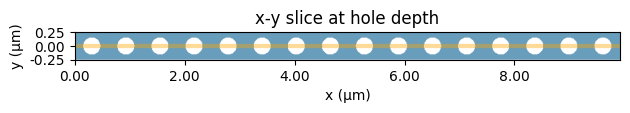

In [42]:
# x-y slice in its own cell
ax = sim.plot(z=z_si_top - etch_depth / 2)
ax.set_xlim(0, grating_length)
ax.set_ylim(-wg_width / 2, wg_width / 2)
ax.set_aspect('equal', adjustable='box')
ax.set_title('x-y slice at hole depth')
plt.show()

In [43]:
sim.plot_3d()